# Projeto — Fase 1: Precificação de Imóveis - King County

**Variável-alvo:** `price`

**Objetivo de negócio:** Estimar o valor de venda de imóveis no condado de 
King County (EUA) a partir de características físicas e de localização, 
para apoiar decisões de compra, venda ou financiamento.

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/kc_house_data.csv")


In [62]:
df.shape

(21613, 21)

In [63]:
df.dtypes

id                 int64
date                 str
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above       float64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

# O que notei nessa etapa abaixo:
1. **Valores ausentes em sqft_above:** No count da tabela: a maioria das colunas tem 21613, mas sqft_above mostra 21611. Isso indica 2 valores ausentes nessa coluna — é algo que irei precisar tratar na Fase 2 (Data Prep).
2. **Outlier claro em bedrooms:** O max de bedrooms é 33.000000 — 33 quartos é, provavelmente, um erro de digitação ou anomalia (provavelmente era pra ser 3), não um imóvel real.
3. **date está como str/object**. Precisarei corrigir isso nas próximas etapas.

In [64]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21611.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.396095,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.128162,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


**Distribuição do preço dos imóveis:** Representado com modelo Gráfico de Histograma.

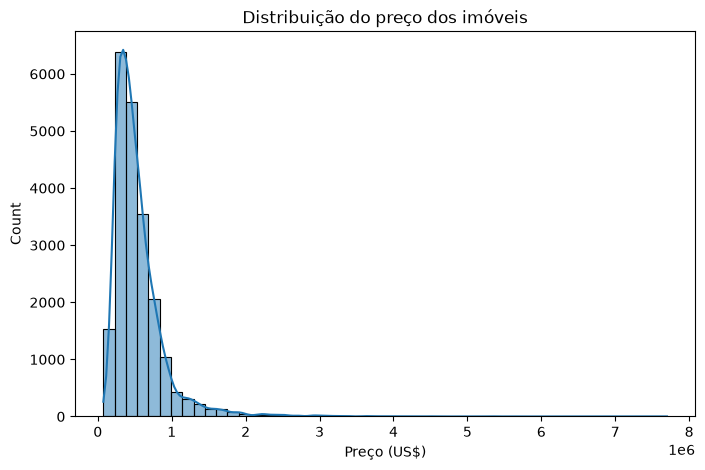

In [65]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Distribuição do preço dos imóveis")
plt.xlabel("Preço (US$)")
plt.savefig("../outputs/figures/hist_price.png")
plt.show()

**Gráfico da Área Construida X Preço:** Representado pelo gráfico de dispersão.

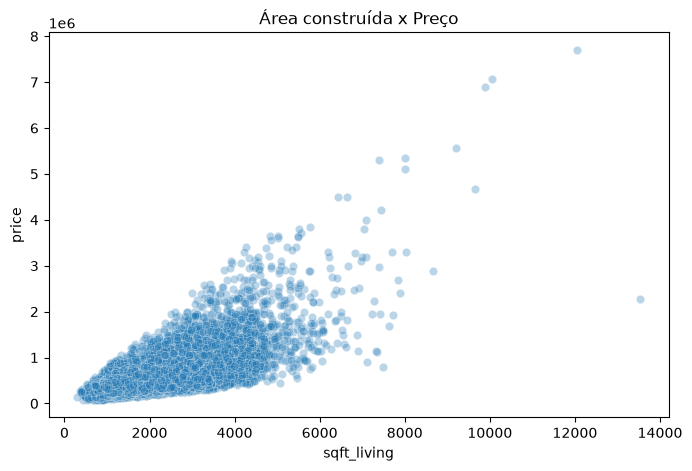

In [66]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["sqft_living"], y=df["price"], alpha=0.3)
plt.title("Área construída x Preço")
plt.savefig("../outputs/figures/scatter_sqftliving_price.png")
plt.show()

**Mapa de Calor (Heatmap), usando a Correlação de Pearson:**

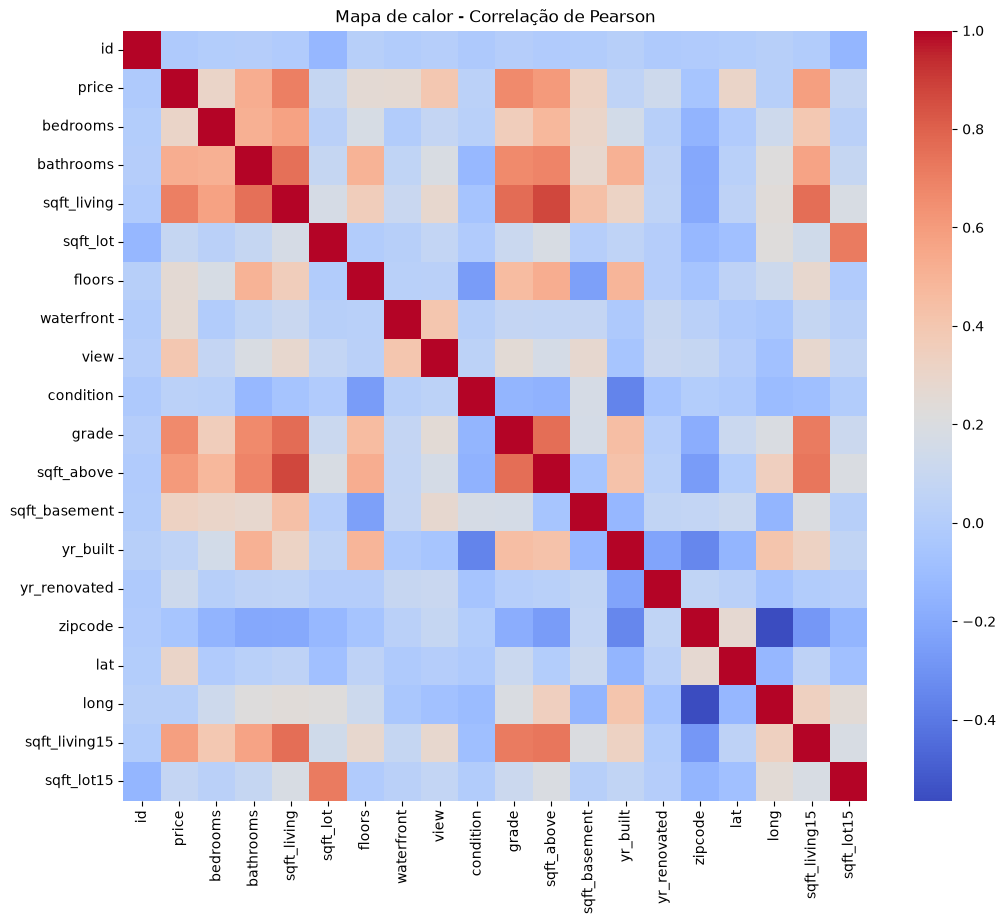

In [67]:
plt.figure(figsize=(12,10))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Mapa de calor - Correlação de Pearson")
plt.savefig("../outputs/figures/heatmap_correlacao.png")
plt.show()

## Análise Crítica dos Resultados após análise dos gráficos acima:

A variável-alvo **price** apresenta forte assimetria à direita, com a maioria 
dos imóveis concentrada em faixas de preço mais baixas e poucos imóveis de 
altíssimo valor puxando a cauda da distribuição. Isso sugere que métricas 
sensíveis a outliers (como a média) podem não representar bem o "imóvel 
típico", e que o modelo de regressão pode ter dificuldade em prever com 
precisão os imóveis mais caros.

A dispersão entre **sqft_living** e **price** mostra uma relação positiva e 
razoavelmente linear, indicando que a área construída é uma forte candidata 
a variável preditora.

O mapa de calor de correlação confirma que **sqft_living**, **grade** e 
**sqft_above** têm as correlações mais fortes com **price**, enquanto variáveis 
como **zipcode** e **condition** têm correlação fraca em formato numérico bruto 
(o que já indica que zipcode vai precisar de tratamento especial, não uso 
direto). Também é possível observar visualmente uma forte correlação entre 
**sqft_living**, **sqft_above** e **sqft_basement**, sinal de multicolinearidade 
que será investigada na Fase 4.

# Fase 2: Tratamento e Limpeza (Data Prep)

In [68]:
print("Linhas duplicadas (todas as colunas iguais):", df.duplicated().sum())
print("IDs duplicados (mesmo imóvel vendido mais de uma vez):", df["id"].duplicated().sum())

Linhas duplicadas (todas as colunas iguais): 0
IDs duplicados (mesmo imóvel vendido mais de uma vez): 177


**Duplicatas:** não foram encontradas linhas 100% duplicadas no dataset. 
Os 177 `id`s repetidos correspondem a imóveis vendidos mais de uma vez em 
datas diferentes (revenda), o que é um dado legítimo e não uma redundância 
de coleta. Por isso, essas linhas foram **mantidas**, sem remoção. O código abaixo seleciona as primeiras 10 linhas (do total ) de todos os registros que possuem IDs repetidos, exibindo-os em ordem crescente de ID.

In [69]:
df[df["id"].duplicated(keep=False)].sort_values("id").head(10)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
2496,1000102,20140916T000000,280000.0,6,3.00,2400,9373,2.0,0,0,...,7,2400.0,0,1991,0,98002,47.3262,-122.214,2060,7316
2497,1000102,20150422T000000,300000.0,6,3.00,2400,9373,2.0,0,0,...,7,2400.0,0,1991,0,98002,47.3262,-122.214,2060,7316
16814,7200179,20141016T000000,150000.0,2,1.00,840,12750,1.0,0,0,...,6,840.0,0,1925,0,98055,47.4840,-122.211,1480,6969
16815,7200179,20150424T000000,175000.0,2,1.00,840,12750,1.0,0,0,...,6,840.0,0,1925,0,98055,47.4840,-122.211,1480,6969
11433,109200390,20140820T000000,245000.0,3,1.75,1480,3900,1.0,0,0,...,7,1480.0,0,1980,0,98023,47.2977,-122.367,1830,6956
11434,109200390,20141020T000000,250000.0,3,1.75,1480,3900,1.0,0,0,...,7,1480.0,0,1980,0,98023,47.2977,-122.367,1830,6956
12417,123039336,20140611T000000,148000.0,1,1.00,620,8261,1.0,0,0,...,5,620.0,0,1939,0,98106,47.5138,-122.364,1180,8244
12418,123039336,20141208T000000,244900.0,1,1.00,620,8261,1.0,0,0,...,5,620.0,0,1939,0,98106,47.5138,-122.364,1180,8244
7792,251300110,20140731T000000,225000.0,3,2.25,2510,12013,2.0,0,0,...,8,2510.0,0,1988,0,98003,47.3473,-122.314,1870,8017
7793,251300110,20150114T000000,358000.0,3,2.25,2510,12013,2.0,0,0,...,8,2510.0,0,1988,0,98003,47.3473,-122.314,1870,8017


**Verificando valores ausentes:**

In [70]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       2
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [71]:
df[df["sqft_above"].isnull()]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
10,1736800520,20150403T000000,662500.0,3,2.5,3560,9796,1.0,0,0,...,8,NaN,1700,1965,0,98007,47.6007,-122.145,2210,8925
17,6865200140,20140529T000000,485000.0,4,1.0,1600,4300,1.5,0,0,...,7,NaN,0,1916,0,98103,47.6648,-122.343,1610,4300


### Tratamento de Valores Ausentes

Foram identificados **2 valores ausentes**, todos na coluna **sqft_above**. Ao investigar as linhas, verifiquei que **sqft_living** e **sqft_basement** estão preenchidos em ambos os casos. Como existe a relação matemática **sqft_living = sqft_above + sqft_basement**, optei por uma **imputação lógica exata** (**sqft_above = sqft_living - sqft_basement**), em vez de imputação estatística por média ou mediana. Essa abordagem é mais precisa pois reconstrói o valor real do imóvel a partir de uma relação conhecida entre as variáveis, ao invés de estimar um valor aproximado. No código abaixo farei a confirmação de que não terão mais valores ausentes.

In [72]:
df["sqft_above"] = df["sqft_above"].fillna(df["sqft_living"] - df["sqft_basement"])
df.isnull().sum()  # confirmar que zerou

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

### Detecção e Tratamento de Outliers

Para identificar valores discrepantes, fiz a análise dos boxplots das variáveis **price**, **bedrooms** e **sqft_living**. A análise do **describe()** 
já havia revelado um valor máximo de 33 quartos em **bedrooms**, o que é fisicamente improvável e sugere erro de digitação.

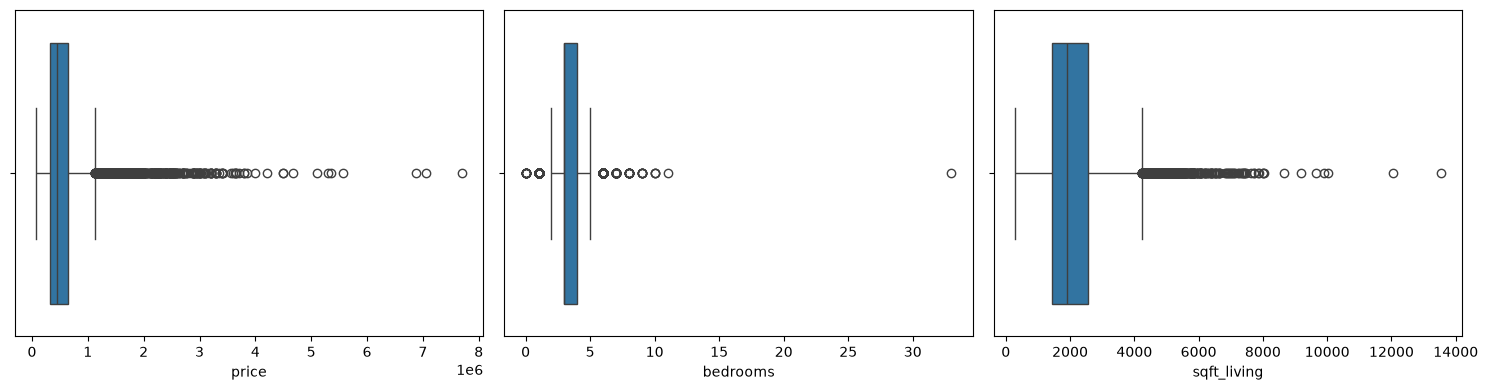

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.boxplot(x=df["price"], ax=axes[0])
sns.boxplot(x=df["bedrooms"], ax=axes[1])
sns.boxplot(x=df["sqft_living"], ax=axes[2])
plt.tight_layout()
plt.savefig("../outputs/figures/boxplots_outliers.png")
plt.show()

In [74]:
df[df["bedrooms"] > 10]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
8757,1773100755,20140821T000000,520000.0,11,3.00,3000,4960,2.0,0,0,...,7,2400.0,600,1918,1999,98106,47.5560,-122.363,1420,4960
15870,2402100895,20140625T000000,640000.0,33,1.75,1620,6000,1.0,0,0,...,7,1040.0,580,1947,0,98103,47.6878,-122.331,1330,4700


Ao investigar os dois registros com mais de 10 quartos, observei que:
- O imóvel com **11 quartos** possui 3.000 sqft de área construída e 3 banheiros — proporção plausível para um imóvel real (ex.: pensão ou casa com várias famílias). Esse decidi que fosse **mantido**. 
- O imóvel com **33 quartos** possui apenas 1.620 sqft de área construída e 1,75 banheiro — isso resultaria em menos de 50 sqft por quarto, o que é fisicamente inviável. Trata-se de um **erro de digitação** (provavelmente o valor correto seria 3 quartos). Essa linha foi **removida** do dataset, já que não há como confirmar o valor real com segurança.
   - Quanto aos demais outliers visíveis nos boxplots de **price** e **sqft_living** (pontos além dos "bigodes" do boxplot), optei por **mantê-los**. Eles representam imóveis de alto padrão genuínos (mansões, propriedades de grande área), e não erros de coleta, e a remoção enviesaria o modelo, reduzindo sua capacidade de prever corretamente a faixa de imóveis mais caros.

In [75]:
df = df[df["id"] != 2402100895]
df.shape  # confirmar que caiu 1 linha (deve ir de 21613 para 21612)

(21612, 21)

# Fase 3: Feature Engineering

Nesta fase criei três novas colunas derivadas de variáveis já existentes:

- **idade_imovel**: idade do imóvel no momento da venda (ano de venda menos ano de construção). Ajuda o modelo a capturar depreciação/valorização 
ligada ao tempo, de forma mais direta do que ***yr_built*** isoladamente. 
- **foi_reformado**: indicador binário (0/1) se o imóvel já passou por reforma. Reformas tendem a agregar valor ao imóvel, então essa variável pode ajudar o modelo a capturar esse efeito. 
- **preco_por_m2**: apenas para fins de leitura/EDA (não será usada como variável preditora, pois deriva diretamente de ***price*** e causaria 
vazamento de dados).

In [76]:
df["date"] = pd.to_datetime(df["date"])
df["ano_venda"] = df["date"].dt.year
df["idade_imovel"] = df["ano_venda"] - df["yr_built"]
df["foi_reformado"] = (df["yr_renovated"] > 0).astype(int)
df["preco_por_m2"] = df["price"] / df["sqft_living"]

df[["date", "ano_venda", "yr_built", "idade_imovel", "yr_renovated", "foi_reformado", "preco_por_m2"]].head()

,date,ano_venda,yr_built,idade_imovel,yr_renovated,foi_reformado,preco_por_m2
0,2014-10-13,2014,1955,59,0,0,188.050847
1,2014-12-09,2014,1951,63,1991,1,209.338521
2,2015-02-25,2015,1933,82,0,0,233.766234
3,2014-12-09,2014,1965,49,0,0,308.163265
4,2015-02-18,2015,1987,28,0,0,303.571429


In [77]:
print("Menor idade_imovel:", df["idade_imovel"].min())
print("Imóveis com idade negativa:", (df["idade_imovel"] < 0).sum())

Menor idade_imovel: -1
Imóveis com idade negativa: 12


In [78]:
df[df["idade_imovel"] < 0][["date", "yr_built", "idade_imovel", "price", "condition"]]

,date,yr_built,idade_imovel,price,condition
1763,2014-06-25,2015,-1,597326.0,3
2687,2014-10-29,2015,-1,385195.0,3
7526,2014-12-31,2015,-1,614285.0,3
8039,2014-06-24,2015,-1,455000.0,3
14489,2014-08-26,2015,-1,500000.0,3
17098,2014-06-17,2015,-1,350000.0,3
19805,2014-08-01,2015,-1,455000.0,3
20770,2014-08-28,2015,-1,357000.0,3
20852,2014-07-09,2015,-1,595000.0,3
20963,2014-07-31,2015,-1,230000.0,3


Foram encontrados 12 registros com ***idade_imovel = -1***, todos com ***yr_built = 2015*** e venda em 2014, ou seja, diferença de exatamente 1 ano em todos os casos. Isso é consistente com vendas de imóveis "na planta" (venda antes da conclusão oficial da construção). Como os demais dados desses registros são válidos e coerentes (preços e condição dentro do padrão do dataset), optei por **não remover** as linhas, mas sim ajustar a idade negativa para 0 (tratando esses imóveis como novos no momento da venda).

In [79]:
df["idade_imovel"] = df["idade_imovel"].clip(lower=0)
print("Imóveis com idade negativa após ajuste:", (df["idade_imovel"] < 0).sum())

Imóveis com idade negativa após ajuste: 0


# Fase 4: Preparação para Modelagem

## Encoding:
As variáveis ***waterfront***, ***view***, ***condition*** e ***grade*** já são numéricas ordinais e serão usadas diretamente, sem necessidade de codificação. 
A variável ***zipcode*** é nominal (categórica sem ordem), e por possuir dezenas de valores únicos, não será usada diretamente — optou-se por usar 
***lat*** e ***long*** como proxy de localização, que já capturam a informação geográfica de forma contínua e sem gerar dezenas de colunas extras.

In [80]:
features = ["bedrooms","bathrooms","sqft_living","sqft_lot","floors",
            "waterfront","view","condition","grade","sqft_above",
            "sqft_basement","idade_imovel","foi_reformado","lat","long"]

X = df[features]
y = df["price"]

X.shape, y.shape

((21612, 15), (21612,))

## Multicolinearidade

Antes de treinar o modelo, é importante avaliar a multicolinearidade entre as variáveis explicativas. Aparentemente ***sqft_above*** e ***sqft_basement*** possam ser altamente correlacionadas com ***sqft_living*** (já que ***sqft_living = sqft_above + sqft_basement***), o que pode inflar artificialmente os coeficientes do modelo de Regressão Linear.

In [81]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data.sort_values("VIF", ascending=False)

c:\Users\lgert\kc-house-precificacao\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
2,sqft_living,inf
9,sqft_above,inf
10,sqft_basement,inf
13,lat,1.194390e+05
14,long,1.185252e+05
8,grade,1.328529e+02
7,condition,3.478883e+01
1,bathrooms,2.862896e+01
0,bedrooms,2.509087e+01
4,floors,1.632031e+01


O resultado confirmou VIF infinito para ***sqft_living***, ***sqft_above*** e ***sqft_basement***, evidenciando colinearidade perfeita entre essas variáveis (pois ***sqft_living*** é exatamente a soma das outras duas). Mantive apenas ***sqft_living***, por ser a variável com maior correlação direta com ***price*** observada no heatmap da Fase 1, e removi ***sqft_above*** e ***sqft_basement*** do conjunto de variáveis preditoras, por serem redundantes.

Os valores elevados de VIF em ***lat*** e ***long*** não indicam multicolinearidade real: são causados pela ausência de centralização dessas variáveis (o cálculo do VIF do ***statsmodels*** não adiciona intercepto automaticamente). Esse efeito será corrigido na etapa seguinte, ao aplicar o ***StandardScaler***.

In [82]:
features = ["bedrooms","bathrooms","sqft_living","sqft_lot","floors",
            "waterfront","view","condition","grade",
            "idade_imovel","foi_reformado","lat","long"]

X = df[features]
y = df["price"]

X.shape

(21612, 13)

## Divisão Amostral (Split) e Escalonamento

O conjunto de dados será dividido em 80% treino / 20% teste. O ***StandardScaler*** será aplicado com ***fit_transform*** apenas no treino (para 
que o modelo não "veja" estatísticas do teste) e ***transform*** no teste, evitando vazamento de dados entre os conjuntos.

In [83]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Treino:", X_train_scaled.shape)
print("Teste:", X_test_scaled.shape)

Treino: (17289, 13)
Teste: (4323, 13)


# Fase 5: Modelagem, Validação e Diagnóstico de Overfitting

Será treinado um modelo de Regressão Linear com os dados de treino escalonados, e o desempenho será comparado entre treino e teste para diagnosticar possível overfitting (quando o erro no treino é muito menor que no teste, indicando que o modelo memorizou os dados em vez de generalizar).

In [84]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)

pred_train = modelo.predict(X_train_scaled)
pred_test = modelo.predict(X_test_scaled)

In [85]:
from sklearn.metrics import mean_squared_error

rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

print(f"RMSE treino: {rmse_train:,.2f}")
print(f"RMSE teste:  {rmse_test:,.2f}")
print(f"Diferença: {abs(rmse_test - rmse_train):,.2f}")

RMSE treino: 200,265.58
RMSE teste:  214,489.43
Diferença: 14,223.85


## Diagnóstico de Overfitting

O RMSE (Raiz do Erro Quadrático Médio) de treino (R$ 200.265,58) e de teste (R$ 214.489,43) apresentam diferença relativamente pequena (≈7%, R$ 14.223,85). Isso indica que o modelo **não apresenta overfitting significativo** — o erro no conjunto de teste não é muito maior que no treino, o que sugere boa capacidade de generalização para dados não vistos. Um cenário de overfitting seria caracterizado por um RMSE de treino muito menor que o de teste (diferença de várias dezenas de %), o que não é o caso aqui.

# Fase 6: Avaliação, Interpretação e Versionamento do Modelo

In [86]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, pred_test)
mse = mean_squared_error(y_test, pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred_test)

print(f"MAE:  {mae:,.2f}")
print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:.4f}")

MAE:  127,599.03
MSE:  46,005,714,494.72
RMSE: 214,489.43
R²:   0.6935


Após calcular as métricas MAE (Erro Absoluto Médio), MSE (Erro Quadrático Médio), RMSE (Raiz do Erro Quadrático Médio) e R² (Coeficiente de Determinação), conclui-se que o R² de ~0,69 significa que o modelo explica cerca de 69% da variação nos preços dos imóveis — um resultado razoável para um modelo linear simples, mas ainda deixa ~31% de variação não explicada (que pode estar ligada a fatores não capturados linearmente, como bairro específico, acabamento, vista, etc — coisas que zipcode bruto ou uma relação não-linear poderiam capturar melhor).
Vamos aos gráficos analíticos exigidos, depois ao veredito de negócio:

# Análise Gráfica:

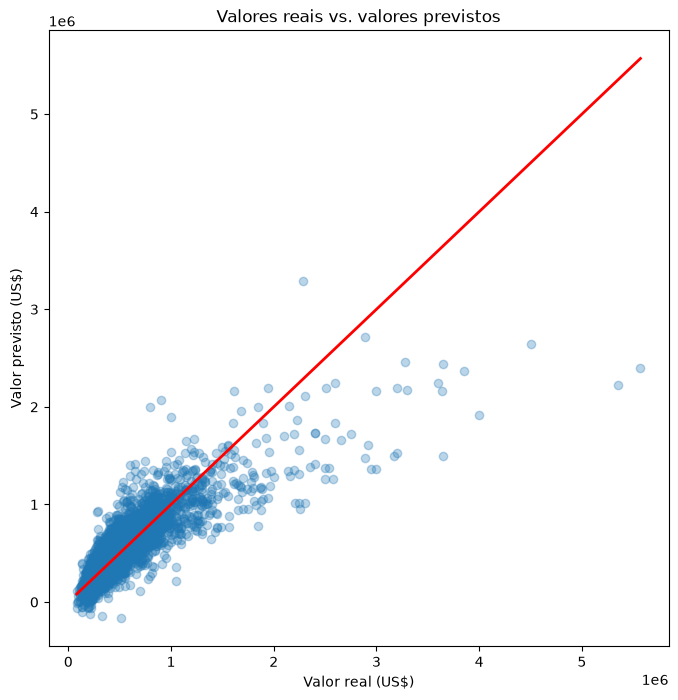

In [87]:
plt.figure(figsize=(8,8))
plt.scatter(y_test, pred_test, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linewidth=2)
plt.xlabel("Valor real (US$)")
plt.ylabel("Valor previsto (US$)")
plt.title("Valores reais vs. valores previstos")
plt.savefig("../outputs/figures/real_vs_previsto.png")
plt.show()

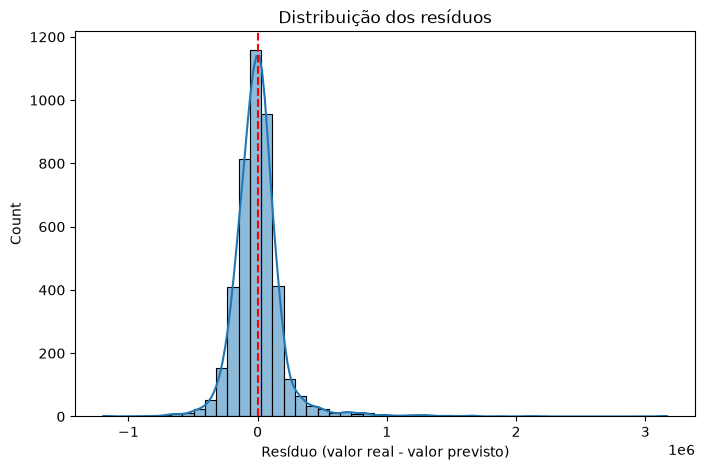

In [88]:
residuos = y_test - pred_test

plt.figure(figsize=(8,5))
sns.histplot(residuos, bins=50, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Resíduo (valor real - valor previsto)")
plt.title("Distribuição dos resíduos")
plt.savefig("../outputs/figures/residuos.png")
plt.show()

## Veredito de Negócio

O gráfico de valores reais vs. previstos mostra boa aderência à linha de ajuste perfeito na faixa de imóveis de baixo e médio valor, mas revela maior dispersão e subestimação sistemática nos imóveis de alto padrão (acima de US$ 2 milhões) — o modelo tende a prever valores menores do que o real para essas propriedades.

O histograma dos resíduos mostra uma distribuição aproximadamente concentrada em torno de zero, com formato próximo ao normal, mas com leve assimetria à direita. Isso é coerente com a limitação observada no gráfico anterior: os erros positivos (subestimação) tendem a ser maiores em magnitude do que os erros negativos, concentrados justamente nos imóveis mais caros.


O modelo apresentou um MAE de aproximadamente **US$ 127.599**, o que significa que, em média, a estimativa de preço de um imóvel erra nesse valor para mais ou para menos. Considerando que o preço médio dos imóveis no dataset gira em torno de US$ 540.000, esse erro representa cerca de **23% do valor médio do imóvel** — uma margem relevante.

Para uma decisão de **compra ou venda pontual**, essa margem é significativa e não deveria ser usada isoladamente para definir um preço final, mas sim como uma **estimativa inicial de referência**, a ser refinada com avaliação presencial e comparação direta com imóveis similares na região.

Para uma decisão de **financiamento** (onde bancos costumam trabalhar com margens de segurança e avaliações próprias), o modelo pode servir como uma ferramenta de triagem rápida, mas não substitui uma avaliação formal.

O R² de 0,69 indica que o modelo captura boa parte da variação de preços, mas ainda há espaço de melhoria — possivelmente incluindo ***zipcode*** de forma mais elaborada (agrupamento por região) ou testando modelos não 
lineares, capazes de capturar relações mais complexas entre localização e preço.

## Versionamento do Modelo (v1)

In [89]:
import pickle, json, datetime

with open("../models/v1/modelo_regressao_v1.pkl", "wb") as f:
    pickle.dump(modelo, f)

metricas = {
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2": r2,
    "data_treinamento": str(datetime.datetime.now()),
    "variaveis_preditoras": features
}

with open("../models/v1/metricas_v1.json", "w") as f:
    json.dump(metricas, f, indent=4)

print("Modelo e métricas salvos com sucesso em models/v1/")

Modelo e métricas salvos com sucesso em models/v1/


# Demonstração da Modularização (src/)

As funções desenvolvidas ao longo deste notebook foram organizadas em módulos Python dentro da pasta ***src/***, como diferencial de organização do projeto. Abaixo, uma demonstração de que o pipeline completo funciona também a partir desses módulos importados.

In [91]:
import sys
sys.path.append("..")

from src.dataset import load_raw_data
from src.features import limpar_dataset
from src.plots import plot_histograma_price, plot_dispersao_sqftliving_price, plot_heatmap_correlacao, plot_boxplots_outliers, plot_real_vs_previsto, plot_residuos
from src.modeling.train import preparar_dados, treinar_modelo, diagnosticar_overfitting, avaliar_modelo, salvar_modelo

{'rmse_train': np.float64(200265.57729919773), 'rmse_test': np.float64(214489.42746605855), 'diferenca': np.float64(14223.850166860822)}


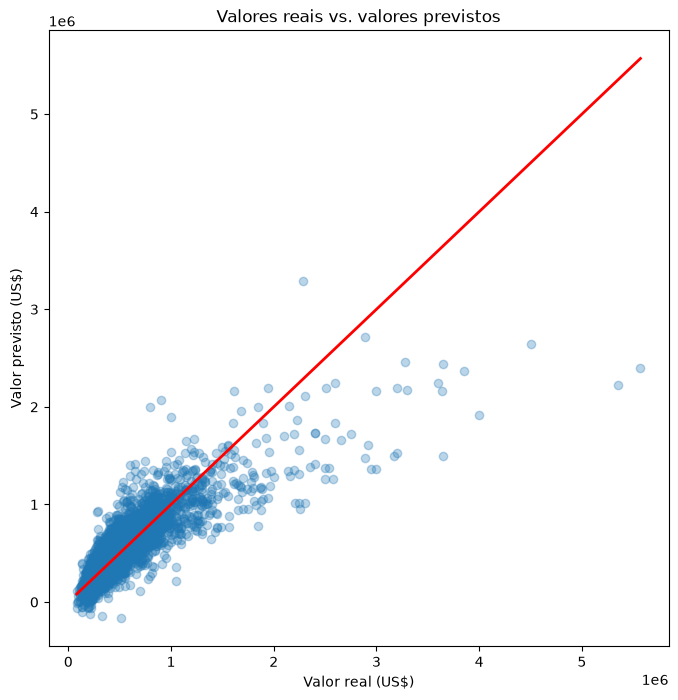

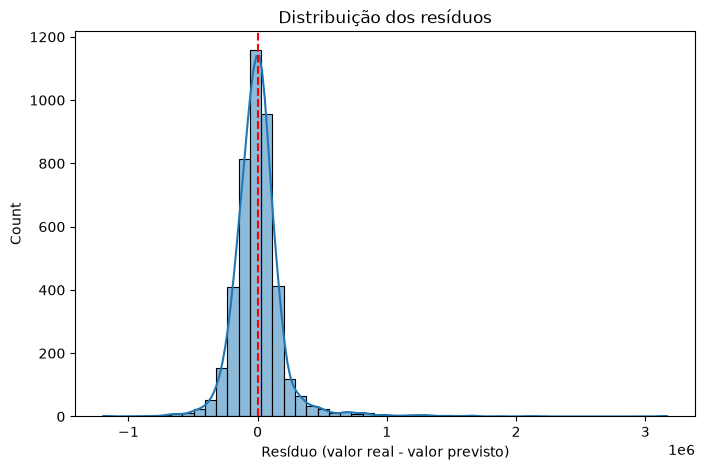

Modelo e métricas salvos com sucesso em models/v1/


In [92]:
df = load_raw_data()
df = limpar_dataset(df)

X_train, X_test, y_train, y_test, scaler = preparar_dados(df)
modelo = treinar_modelo(X_train, y_train)

diagnostico = diagnosticar_overfitting(modelo, X_train, y_train, X_test, y_test)
print(diagnostico)

resultado = avaliar_modelo(modelo, X_test, y_test)
plot_real_vs_previsto(y_test, resultado["pred_test"])
plot_residuos(y_test, resultado["pred_test"])

salvar_modelo(modelo, resultado, versao="v1")